In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.shape

(10000, 8)

In [5]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [7]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [8]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [11]:
for column in df.columns:
    print("\nColumn:", column)
    print(df[column].unique()[:10])


Column: Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411'
 'TXN_2602893' 'TXN_4433211' 'TXN_6699534' 'TXN_4717867' 'TXN_2064365']

Column: Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice']

Column: Quantity
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]

Column: Price Per Unit
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']

Column: Total Spent
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0']

Column: Payment Method
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

Column: Location
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

Column: Transaction Date
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31']


In [13]:
df.hist(figsize=(12,10))
plt.show()

ValueError: hist method requires numerical or datetime columns, nothing to plot.

In [14]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [15]:
numeric_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
df.dtypes

Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object

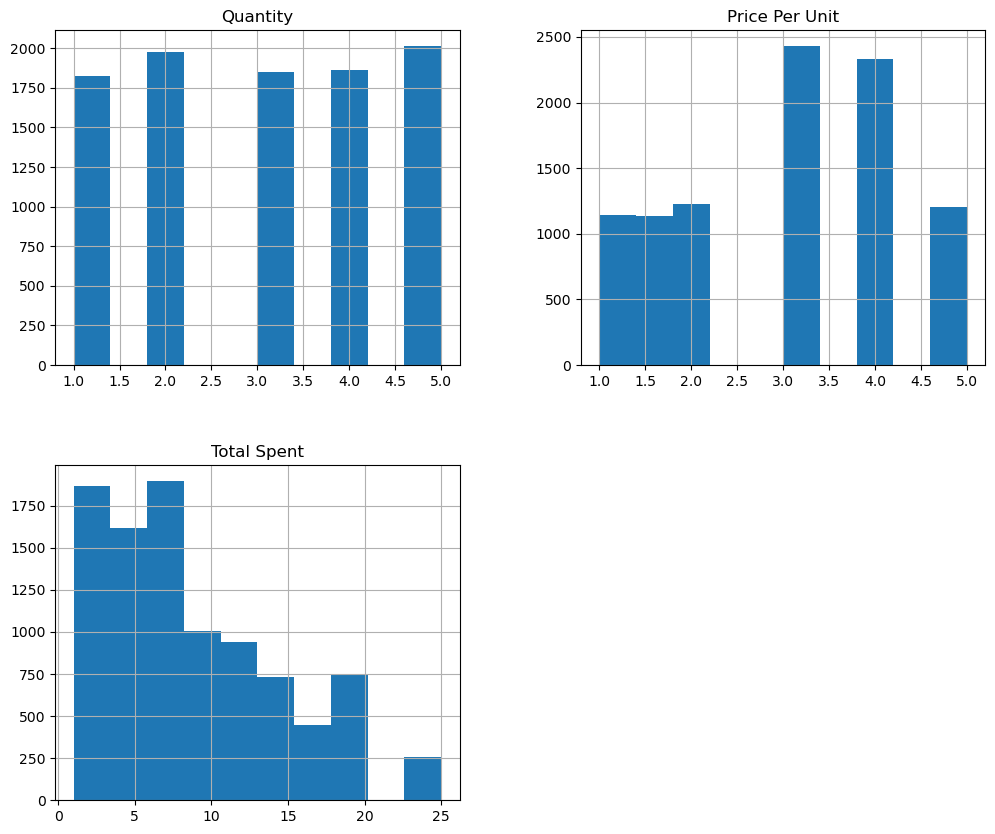

In [17]:
df.hist(figsize=(12,10))
plt.show()

In [18]:
clean_df = df.copy()

In [19]:
clean_df.drop_duplicates(inplace=True)

In [20]:
clean_df.duplicated().sum()

np.int64(0)

In [21]:
numeric_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

for col in numeric_columns:
    clean_df[col].fillna(clean_df[col].mean(), inplace=True)

C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\2421588754.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(clean_df[col].mean(), inplace=True)


In [22]:
categorical_columns = [
    "Item",
    "Payment Method",
    "Location"
]

for col in categorical_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

In [23]:
numeric_columns = [
    "Quantity",
    "Price Per Unit",
    "Total Spent"
]

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mean())

In [24]:
for col in categorical_columns:
    clean_df[col] = clean_df[col].str.strip()
    clean_df[col] = clean_df[col].str.title()

In [25]:
clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors='coerce'
)

In [26]:
clean_df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [27]:
clean_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.000000,Cash,In-Store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.924352,Credit Card,In-Store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.000000,Digital Wallet,In-Store,2023-06-11


In [28]:
clean_df["Transaction Date"].fillna(
    clean_df["Transaction Date"].mode()[0],
    inplace=True
)

C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\4242612297.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df["Transaction Date"].fillna(


In [29]:
clean_df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [30]:
clean_df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.000000,Cash,In-Store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.924352,Credit Card,In-Store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.000000,Digital Wallet,In-Store,2023-06-11


In [31]:
clean_df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [32]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              10000 non-null  object        
 2   Quantity          10000 non-null  float64       
 3   Price Per Unit    10000 non-null  float64       
 4   Total Spent       10000 non-null  float64       
 5   Payment Method    10000 non-null  object        
 6   Location          10000 non-null  object        
 7   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [33]:
summary_report = clean_df.describe(include='all')

In [34]:
summary_report

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000,10000
unique,10000,10,NaN,NaN,NaN,5,4,NaN
top,TXN_1961373,Juice,NaN,NaN,NaN,Digital Wallet,Takeaway,NaN
freq,1,1504,NaN,NaN,NaN,4870,6287,NaN
mean,NaN,NaN,3.028463,2.949984,8.924352,NaN,NaN,2023-06-25 05:52:13.440000
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,2023-01-01 00:00:00
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,2023-03-19 00:00:00
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,2023-06-24 00:00:00
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,2023-09-27 00:00:00
max,NaN,NaN,5.000000,5.000000,25.000000,NaN,NaN,2023-12-31 00:00:00


In [35]:
summary_report.to_csv("summary_report.csv")

In [36]:
sales_by_item = clean_df.groupby("Item")["Total Spent"].sum()

In [37]:
sales_by_item

Item
Cake        10388.141977
Coffee       7230.217625
Cookie       3578.688092
Error        2605.213992
Juice       13510.931617
Salad       17069.066330
Sandwich    13545.007265
Smoothie    13198.553380
Tea          5163.868920
Unknown      2953.835755
Name: Total Spent, dtype: float64

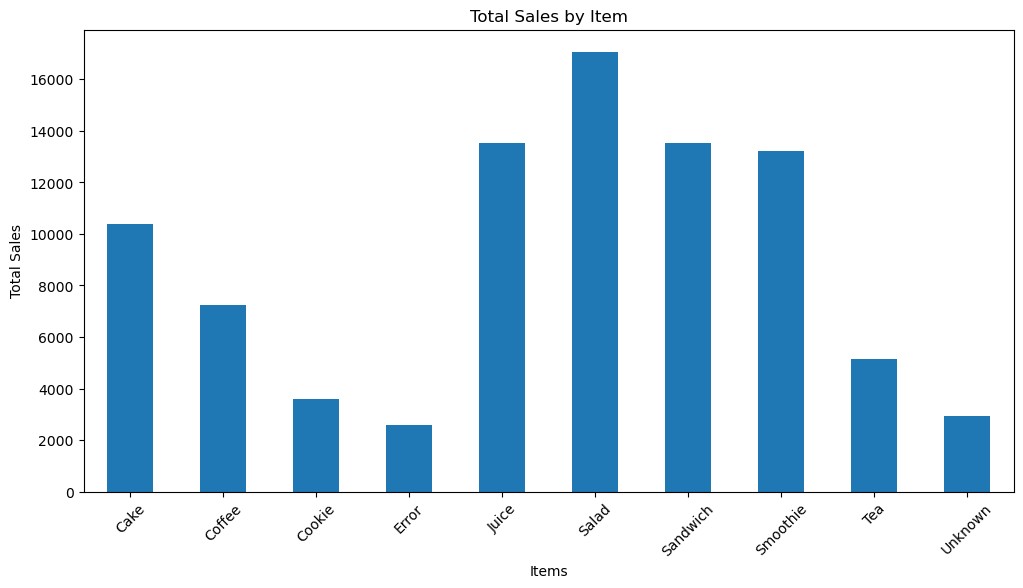

In [38]:
plt.figure(figsize=(12,6))

sales_by_item.plot(kind='bar')

plt.title("Total Sales by Item")

plt.xlabel("Items")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [39]:
payment_counts = clean_df["Payment Method"].value_counts()

In [40]:
payment_counts

Payment Method
Digital Wallet    4870
Credit Card       2273
Cash              2258
Error              306
Unknown            293
Name: count, dtype: int64

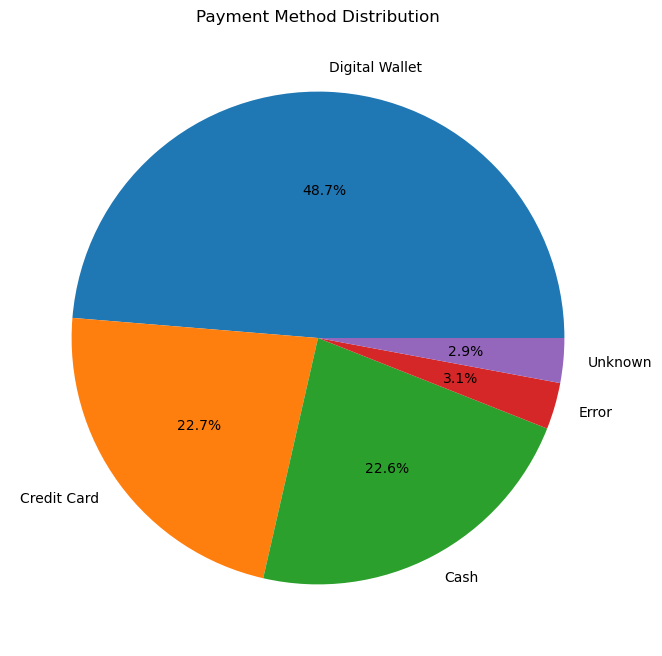

In [41]:
plt.figure(figsize=(8,8))

payment_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

In [42]:
location_sales = clean_df.groupby("Location")["Total Spent"].sum()

In [43]:
location_sales

Location
Error        3275.289640
In-Store    27226.804169
Takeaway    55939.868446
Unknown      2801.562697
Name: Total Spent, dtype: float64

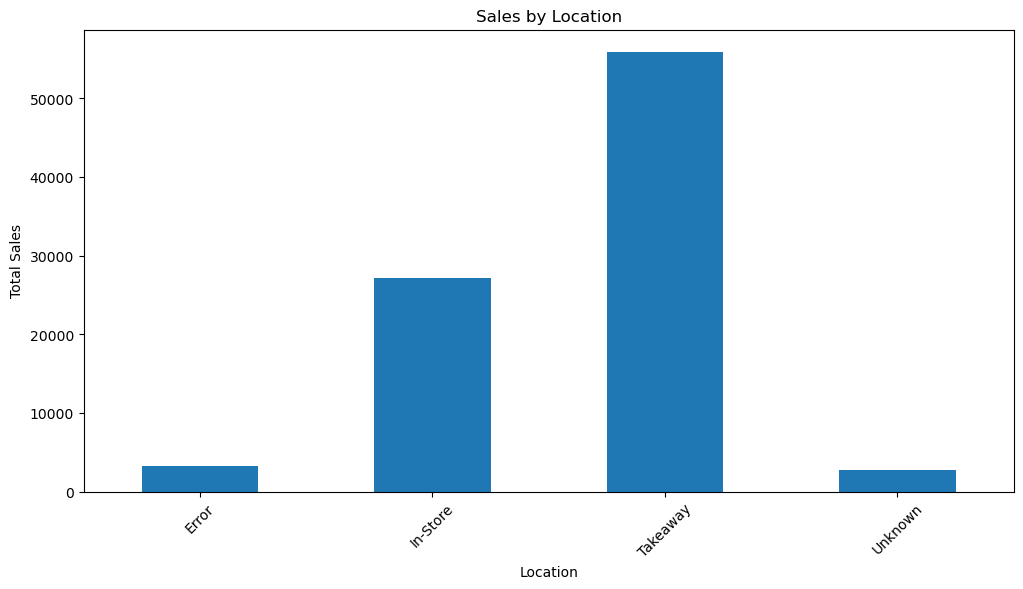

In [44]:
plt.figure(figsize=(12,6))

location_sales.plot(kind='bar')

plt.title("Sales by Location")

plt.xlabel("Location")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [45]:
clean_df["Month"] = clean_df["Transaction Date"].dt.month

In [46]:
monthly_sales = clean_df.groupby("Month")["Total Spent"].sum()

In [47]:
monthly_sales

Month
1      7264.444567
2     10811.385502
3      7241.444567
4      7185.641977
5      7004.201042
6      7357.079280
7      6948.822805
8      7136.033165
9      6867.398452
10     7370.701042
11     6925.171510
12     7131.201042
Name: Total Spent, dtype: float64

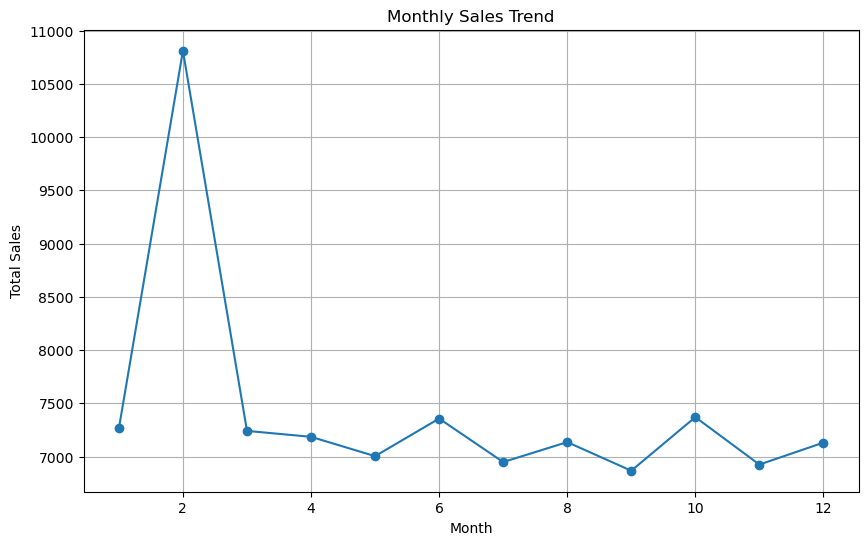

In [48]:
plt.figure(figsize=(10,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

In [49]:
clean_df.to_excel("automated_clean_report.xlsx", index=False)

In [50]:
import os

os.makedirs("reports", exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [51]:
def generate_summary_report(dataframe):
    
    summary = dataframe.describe(include='all')
    
    summary.to_csv("reports/summary_report.csv")
    
    print("Summary report generated successfully.")

In [52]:
generate_summary_report(clean_df)

Summary report generated successfully.


In [53]:
def missing_value_report(dataframe):
    
    missing = dataframe.isnull().sum()
    
    missing.to_csv("reports/missing_values_report.csv")
    
    print("Missing value report generated.")

In [54]:
missing_value_report(clean_df)

Missing value report generated.


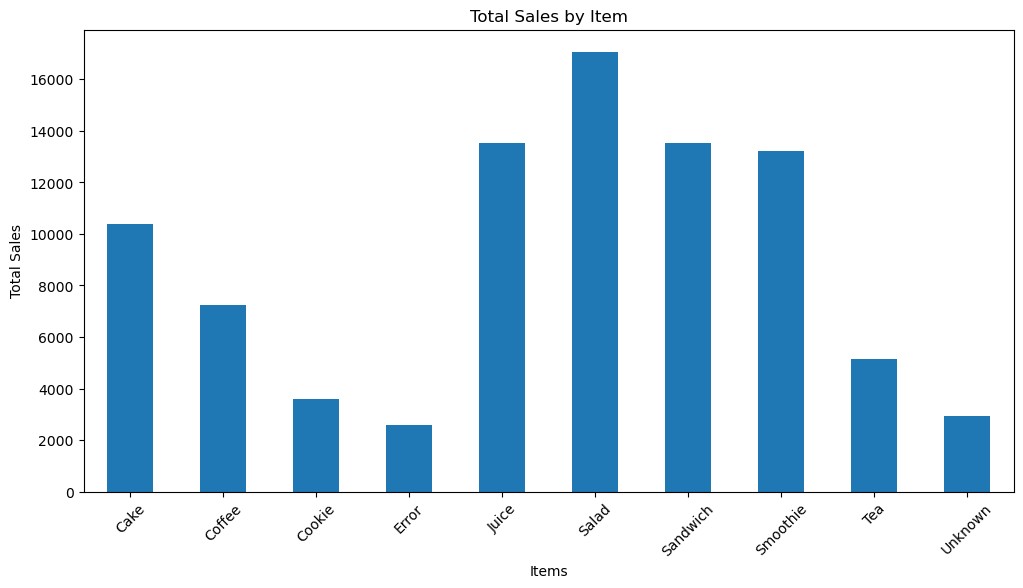

In [55]:
plt.figure(figsize=(12,6))

sales_by_item.plot(kind='bar')

plt.title("Total Sales by Item")

plt.xlabel("Items")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("charts/sales_by_item.png")

plt.show()

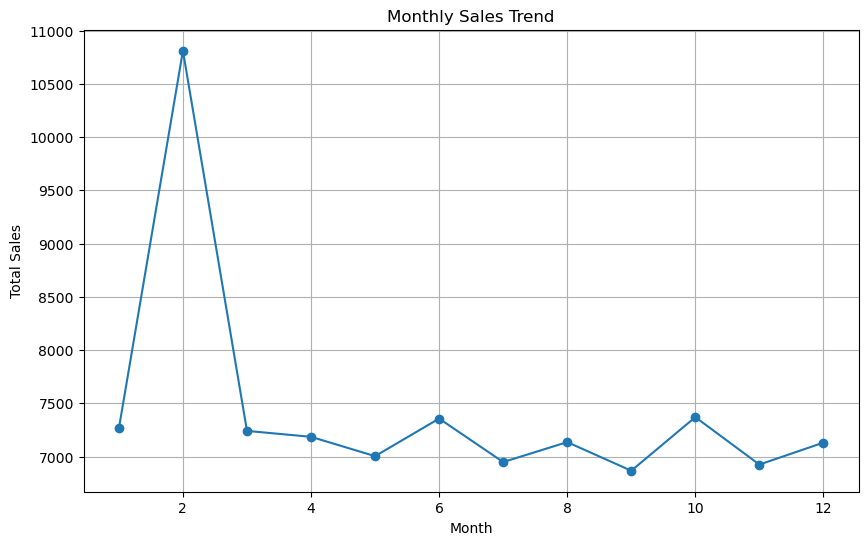

In [56]:
plt.figure(figsize=(10,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

In [57]:
with pd.ExcelWriter("reports/final_automated_report.xlsx") as writer:
    
    clean_df.to_excel(writer, sheet_name='Cleaned Data', index=False)
    
    summary_report.to_excel(writer, sheet_name='Summary Report')
    
print("Excel report generated successfully.")

Excel report generated successfully.


In [58]:
def full_data_cleaning_pipeline(dataframe):

    # Remove duplicates
    dataframe.drop_duplicates(inplace=True)

    # Numeric columns
    numeric_columns = [
        "Quantity",
        "Price Per Unit",
        "Total Spent"
    ]

    for col in numeric_columns:
        dataframe[col] = pd.to_numeric(dataframe[col], errors='coerce')
        dataframe[col].fillna(dataframe[col].mean(), inplace=True)

    # Categorical columns
    categorical_columns = [
        "Item",
        "Payment Method",
        "Location"
    ]

    for col in categorical_columns:
        dataframe[col].fillna(dataframe[col].mode()[0], inplace=True)
        dataframe[col] = dataframe[col].str.strip()
        dataframe[col] = dataframe[col].str.title()

    # Date conversion
    dataframe["Transaction Date"] = pd.to_datetime(
        dataframe["Transaction Date"],
        errors='coerce'
    )

    dataframe["Transaction Date"].fillna(
        dataframe["Transaction Date"].mode()[0],
        inplace=True
    )

    print("Full cleaning pipeline completed.")

    return dataframe

In [59]:
automated_df = full_data_cleaning_pipeline(df.copy())

Full cleaning pipeline completed.


C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\311650614.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[col].fillna(dataframe[col].mean(), inplace=True)
C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\311650614.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [60]:
full_data_cleaning_pipeline(df)

Full cleaning pipeline completed.


C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\311650614.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataframe[col].fillna(dataframe[col].mean(), inplace=True)
C:\Users\siddhartha\AppData\Local\Temp\ipykernel_34036\311650614.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.000000,4.000000,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.000000,12.000000,Cash,In-Store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.000000,8.924352,Credit Card,In-Store,2023-07-19
3,TXN_7034554,Salad,2.0,5.000000,10.000000,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2.0,2.000000,4.000000,Digital Wallet,In-Store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.000000,4.000000,Digital Wallet,Unknown,2023-08-30
9996,TXN_9659401,Juice,3.0,2.949984,3.000000,Digital Wallet,Takeaway,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.000000,8.000000,Digital Wallet,Takeaway,2023-03-02
9998,TXN_7695629,Cookie,3.0,2.949984,3.000000,Digital Wallet,Takeaway,2023-12-02


In [61]:
automated_df.to_csv("reports/final_cleaned_dataset.csv", index=False)